# Model 3 — Sentence-BERT (SBERT) Fine-tuning

**Goal:** Beat Models 1 and 2 using contextual transformer embeddings fine-tuned on our specific task.

### Strategy
1. Start from `sentence-transformers/all-MiniLM-L6-v2` — 22M params, fast, strong baseline embeddings
2. Fine-tune using **CosineSimilarityLoss** on combined PAN + Quora training pairs
3. At inference: embed both passages independently → cosine similarity → threshold

### Why SBERT over vanilla BERT?
- Vanilla BERT needs both sentences simultaneously (slow for millions of pairs)
- SBERT produces fixed sentence embeddings — each passage encoded once, then compared via cosine
- Pre-trained on 1B+ sentence pairs — strong starting point for semantic similarity

## 1. Setup

In [1]:
!pip install -q sentence-transformers

In [2]:
import os, sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from torch.utils.data import DataLoader

from sentence_transformers import (
    SentenceTransformer,
    InputExample,
    losses,
    evaluation,
)
from sentence_transformers.evaluation import BinaryClassificationEvaluator

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report)
from sklearn.metrics.pairwise import cosine_similarity

from google.colab import drive
drive.mount('/content/drive')

PROCESSED_DIR = Path('/content/drive/MyDrive/pan-processed')
RESULTS_DIR   = Path('results');        RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR    = Path('trained_models'); MODELS_DIR.mkdir(exist_ok=True)

DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## 2. Inline data loader

In [3]:
def load_pan():
    train = pd.read_csv(PROCESSED_DIR / 'pan_train.csv')
    val   = pd.read_csv(PROCESSED_DIR / 'pan_val.csv')
    test  = pd.read_csv(PROCESSED_DIR / 'pan_test.csv')
    return train, val, test

def load_quora():
    train = pd.read_csv(PROCESSED_DIR / 'quora_train.csv')
    test  = pd.read_csv(PROCESSED_DIR / 'quora_test.csv')
    return train, test

def build_pan_pairs(df_pan):
    np.random.seed(RANDOM_STATE)
    pos = df_pan[
        (df_pan['is_plagiarism'] == 1) &
        (df_pan['corpus_type']  == 'external') &
        (df_pan['source_text'].notna()) &
        (df_pan['source_text']  != 'NONE')
    ].copy()
    src_pool = pos['source_text'].values
    neg = df_pan[
        (df_pan['is_plagiarism'] == 0) &
        (df_pan['corpus_type']  == 'external')
    ].copy()
    if len(neg) > 0:
        neg['source_text'] = np.random.choice(src_pool, size=len(neg))
    out = pd.concat([pos, neg], ignore_index=True)
    out = out.rename(columns={
        'suspicious_text': 'text_a',
        'source_text'    : 'text_b',
        'is_plagiarism'  : 'label',
    })
    return out[['text_a', 'text_b', 'label', 'plagiarism_type', 'obfuscation']].reset_index(drop=True)

def get_quora_pairs(df):
    return df.rename(columns={
        'q1_clean': 'text_a', 'q2_clean': 'text_b', 'is_duplicate': 'label'
    })[['text_a', 'text_b', 'label']].reset_index(drop=True)

## 3. Load and combine data

In [4]:
pan_train, pan_val, pan_test = load_pan()
pan_train_pairs = build_pan_pairs(pan_train)
pan_val_pairs   = build_pan_pairs(pan_val)
pan_test_pairs  = build_pan_pairs(pan_test)

qtrain, qtest = load_quora()
q_train_pairs = get_quora_pairs(qtrain)
q_test_pairs  = get_quora_pairs(qtest)
q_val_pairs   = q_train_pairs.sample(frac=0.10, random_state=RANDOM_STATE)
q_train_pairs = q_train_pairs.drop(q_val_pairs.index).reset_index(drop=True)
q_val_pairs   = q_val_pairs.reset_index(drop=True)

train_df = pd.concat([pan_train_pairs[['text_a','text_b','label']],
                      q_train_pairs[['text_a','text_b','label']]], ignore_index=True)
val_df   = pd.concat([pan_val_pairs[['text_a','text_b','label']],
                      q_val_pairs[['text_a','text_b','label']]], ignore_index=True)

print('Dataset sizes:')
for name, df in [('Combined train', train_df), ('Combined val', val_df),
                 ('PAN test', pan_test_pairs), ('Quora test', q_test_pairs)]:
    pos = df['label'].sum()
    print(f'  {name:18s} | {len(df):>7,d} rows | pos={pos:>6,d} ({pos/len(df):.1%})')

Dataset sizes:
  Combined train     | 333,785 rows | pos=142,688 (42.7%)
  Combined val       |  40,708 rows | pos=18,705 (45.9%)
  PAN test           |   9,276 rows | pos= 7,647 (82.4%)
  Quora test         |  80,827 rows | pos=29,855 (36.9%)


## 4. Truncate PAN passages for SBERT

SBERT has a 512-token limit. PAN passages average 3,200 chars (~600 tokens).
We truncate to the first 400 words — enough to capture plagiarism signal while staying within limits.

In [ ]:
def truncate_words(text, max_words=400):
    if not isinstance(text, str):
        return ''
    return ' '.join(text.split()[:max_words])

for df in [train_df, val_df, pan_test_pairs, pan_val_pairs]:
    df['text_a'] = df['text_a'].apply(truncate_words)
    df['text_b'] = df['text_b'].apply(truncate_words)

print('Truncation applied. Sample lengths:')
print(f'  train text_a avg words: {train_df["text_a"].str.split().str.len().mean():.0f}')
print(f'  train text_b avg words: {train_df["text_b"].str.split().str.len().mean():.0f}')

Truncation applied. Sample lengths:
  train text_a avg words: 35
  train text_b avg words: 39


## 5. Build SBERT InputExamples

In [5]:
def make_examples(df):
    """Convert DataFrame rows to SBERT InputExample list.
    Label is float in [0, 1] — CosineSimilarityLoss expects this.
    """
    examples = []
    for _, row in df.iterrows():
        examples.append(InputExample(
            texts  = [str(row['text_a']), str(row['text_b'])],
            label  = float(row['label'])
        ))
    return examples

print('Building InputExamples...')
train_examples = make_examples(train_df)
print(f'  Train: {len(train_examples):,} examples')

# Val evaluator — BinaryClassificationEvaluator computes F1/AUC at every checkpoint
val_evaluator = BinaryClassificationEvaluator(
    sentences1  = val_df['text_a'].tolist(),
    sentences2  = val_df['text_b'].tolist(),
    labels      = val_df['label'].astype(int).tolist(),
    name        = 'val',
    show_progress_bar = False,
)
print(f'  Val evaluator: {len(val_df):,} pairs')

Building InputExamples...
  Train: 333,785 examples
  Val evaluator: 40,708 pairs


## 6. Load pretrained SBERT and fine-tune

In [ ]:
MODEL_NAME   = 'sentence-transformers/all-MiniLM-L6-v2'
BATCH_SIZE   = 256   
EPOCHS       = 4     
WARMUP_RATIO = 0.1
SAVE_PATH = '/content/drive/MyDrive/pan-processed/model3_sbert_best'

model = SentenceTransformer(MODEL_NAME)
print(f'Loaded: {MODEL_NAME}')
print(f'Max sequence length: {model.max_seq_length}')
model.max_seq_length = 256  

train_dataloader = DataLoader(
    train_examples,
    shuffle     = True,
    batch_size  = BATCH_SIZE
)

train_loss = losses.CosineSimilarityLoss(model)

warmup_steps = int(len(train_dataloader) * EPOCHS * WARMUP_RATIO)
print(f'\nTraining config:')
print(f'  Epochs      : {EPOCHS}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Steps/epoch : {len(train_dataloader)}')
print(f'  Warmup steps: {warmup_steps}')
print(f'  Save path   : {SAVE_PATH}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: sentence-transformers/all-MiniLM-L6-v2
Max sequence length: 256

Training config:
  Epochs      : 4
  Batch size  : 256
  Steps/epoch : 1304
  Warmup steps: 521
  Save path   : /content/drive/MyDrive/pan-processed/model3_sbert_best


In [11]:
from sentence_transformers import SentenceTransformer

SAVE_PATH  = '/content/drive/MyDrive/pan-processed/model3_sbert_best'
best_model = SentenceTransformer(SAVE_PATH)
print('Model loaded successfully from Drive')
print(f'Max seq length: {best_model.max_seq_length}')

Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

Model loaded successfully from Drive
Max seq length: 256


In [ ]:
model.fit(
    train_objectives  = [(train_dataloader, train_loss)],
    evaluator         = val_evaluator,
    epochs            = EPOCHS,
    warmup_steps      = warmup_steps,
    evaluation_steps  = len(train_dataloader),
    output_path       = '/content/drive/MyDrive/pan-processed/model3_sbert_best', 
    save_best_model   = True,
    show_progress_bar = True,
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss


KeyboardInterrupt: 

## 7. Load best checkpoint

In [11]:
best_model = SentenceTransformer('/content/drive/MyDrive/pan-processed/model3_sbert_best')
print(f'Loaded best model from: /content/drive/MyDrive/pan-processed/model3_sbert_best')

FileNotFoundError: Path /content/drive/MyDrive/pan-processed/model3_sbert_best not found

## 8. Inference — encode and compute cosine similarity

In [ ]:
def get_similarities(df, model, batch_size=256):
    """Encode both columns and return pairwise cosine similarities."""
    a_texts = df['text_a'].fillna('').tolist()
    b_texts = df['text_b'].fillna('').tolist()

    print('  Encoding text_a...')
    emb_a = model.encode(a_texts, batch_size=batch_size,
                         show_progress_bar=True, convert_to_numpy=True)
    print('  Encoding text_b...')
    emb_b = model.encode(b_texts, batch_size=batch_size,
                         show_progress_bar=True, convert_to_numpy=True)

    # Row-wise cosine similarity
    sims = np.einsum('ij,ij->i',
                     emb_a / np.linalg.norm(emb_a, axis=1, keepdims=True),
                     emb_b / np.linalg.norm(emb_b, axis=1, keepdims=True))
    return sims.astype(np.float32)

## 9. Tune thresholds on val sets

Computing val similarities...
  Encoding text_a...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

  Encoding text_b...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

  Encoding text_a...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

  Encoding text_b...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]


Tuning thresholds...
  PAN      best threshold = 0.45  (val F1 = 0.9976)
  Quora    best threshold = 0.58  (val F1 = 0.8091)


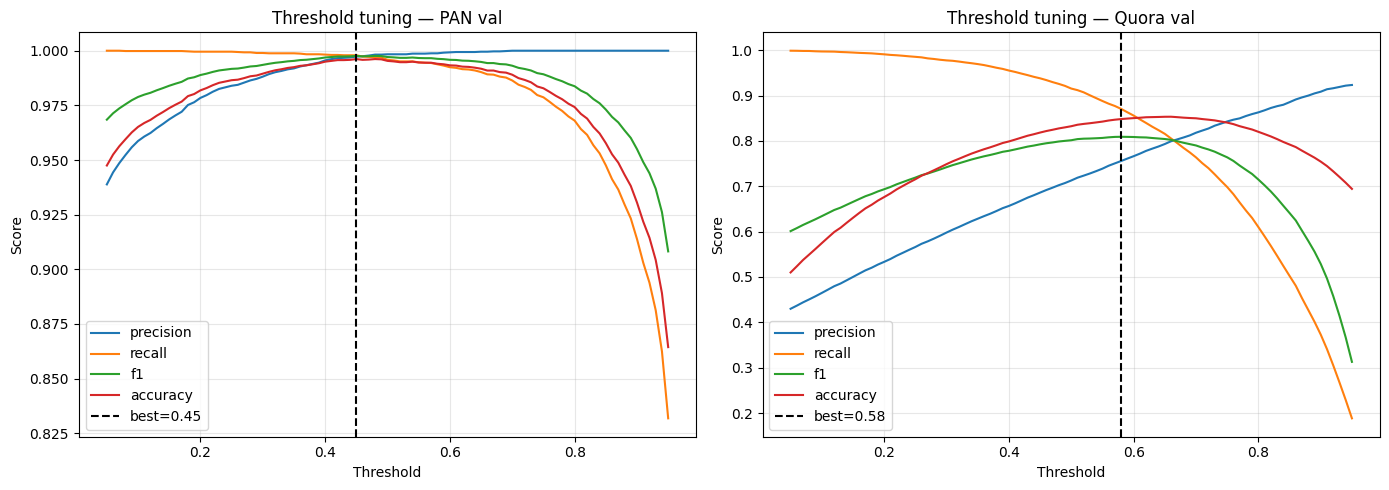


Final thresholds → PAN: 0.45   Quora: 0.58


In [13]:
def find_best_threshold(sims, labels, name):
    thresholds = np.arange(0.05, 0.96, 0.01)
    best_f1, best_t = 0, 0.5
    rows = []
    for t in thresholds:
        preds = (sims >= t).astype(int)
        f1  = f1_score(labels, preds, zero_division=0)
        acc = accuracy_score(labels, preds)
        pre = precision_score(labels, preds, zero_division=0)
        rec = recall_score(labels, preds, zero_division=0)
        rows.append({'threshold': t, 'f1': f1, 'accuracy': acc,
                     'precision': pre, 'recall': rec})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f'  {name:8s} best threshold = {best_t:.2f}  (val F1 = {best_f1:.4f})')
    return best_t, pd.DataFrame(rows)


print('Computing val similarities...')
pan_val_sims = get_similarities(pan_val_pairs, best_model)
q_val_sims   = get_similarities(q_val_pairs,   best_model)

print('\nTuning thresholds...')
PAN_THRESHOLD, pan_thresh_df = find_best_threshold(
    pan_val_sims, pan_val_pairs['label'].values, 'PAN')
Q_THRESHOLD, q_thresh_df = find_best_threshold(
    q_val_sims, q_val_pairs['label'].values, 'Quora')

# Plot threshold curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, thresh_df, best_t, name in [
    (axes[0], pan_thresh_df, PAN_THRESHOLD, 'PAN val'),
    (axes[1], q_thresh_df,   Q_THRESHOLD,   'Quora val'),
]:
    for col, color in [('precision','tab:blue'), ('recall','tab:orange'),
                       ('f1','tab:green'), ('accuracy','tab:red')]:
        ax.plot(thresh_df['threshold'], thresh_df[col], label=col, color=color)
    ax.axvline(best_t, color='black', linestyle='--', label=f'best={best_t:.2f}')
    ax.set_title(f'Threshold tuning — {name}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model3_threshold_tuning.png', dpi=120)
plt.show()
print(f'\nFinal thresholds → PAN: {PAN_THRESHOLD:.2f}   Quora: {Q_THRESHOLD:.2f}')

## 10. Evaluate on test sets

In [14]:
def evaluate(sims, labels, name, threshold):
    preds = (sims >= threshold).astype(int)
    metrics = {
        'dataset'  : name,
        'n'        : len(labels),
        'accuracy' : accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall'   : recall_score(labels, preds, zero_division=0),
        'f1'       : f1_score(labels, preds, zero_division=0),
        'roc_auc'  : roc_auc_score(labels, sims) if len(np.unique(labels)) > 1 else float('nan'),
        'threshold': threshold,
    }
    print(f'\n── {name} ─────────────────────────────────')
    for k, v in metrics.items():
        print(f'  {k:9s}: {v:.4f}' if isinstance(v, float) else f'  {k:9s}: {v}')
    print(f'\n{classification_report(labels, preds, target_names=["non-plag","plagiarism"], zero_division=0)}')
    return metrics, preds


print('Computing test similarities...')
pan_test_sims = get_similarities(pan_test_pairs, best_model)
q_test_sims   = get_similarities(q_test_pairs,   best_model)

pan_metrics, pan_preds = evaluate(
    pan_test_sims, pan_test_pairs['label'].values, 'PAN test', PAN_THRESHOLD)
q_metrics, q_preds = evaluate(
    q_test_sims, q_test_pairs['label'].values, 'Quora test', Q_THRESHOLD)

results_df = pd.DataFrame([pan_metrics, q_metrics])
results_df.to_csv(RESULTS_DIR / 'model3_metrics.csv', index=False)
print('\n── Final Results ──')
print(results_df.to_string(index=False))

Computing test similarities...
  Encoding text_a...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

  Encoding text_b...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

  Encoding text_a...


Batches:   0%|          | 0/158 [00:00<?, ?it/s]

  Encoding text_b...


Batches:   0%|          | 0/158 [00:00<?, ?it/s]


── PAN test ─────────────────────────────────
  dataset  : PAN test
  n        : 9276
  accuracy : 0.9927
  precision: 0.9979
  recall   : 0.9932
  f1       : 0.9955
  roc_auc  : 0.9997
  threshold: 0.4500

              precision    recall  f1-score   support

    non-plag       0.97      0.99      0.98      1629
  plagiarism       1.00      0.99      1.00      7647

    accuracy                           0.99      9276
   macro avg       0.98      0.99      0.99      9276
weighted avg       0.99      0.99      0.99      9276


── Quora test ─────────────────────────────────
  dataset  : Quora test
  n        : 80827
  accuracy : 0.8464
  precision: 0.7536
  recall   : 0.8682
  f1       : 0.8068
  roc_auc  : 0.9242
  threshold: 0.5800

              precision    recall  f1-score   support

    non-plag       0.92      0.83      0.87     50972
  plagiarism       0.75      0.87      0.81     29855

    accuracy                           0.85     80827
   macro avg       0.83      0.85 

## 11. Confusion matrices + ROC

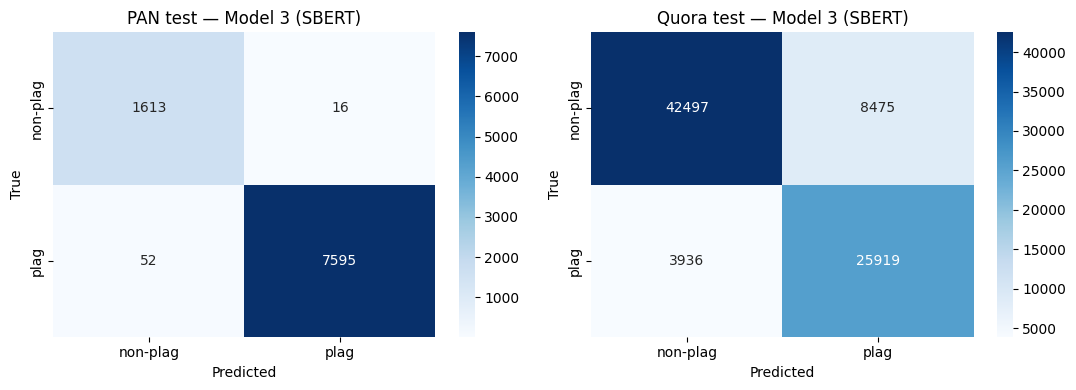

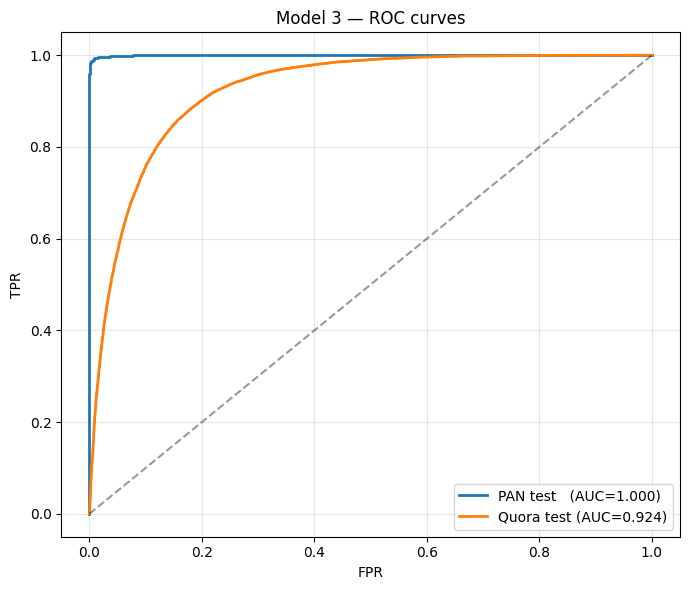

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, labels, preds) in zip(axes, [
    ('PAN test',   pan_test_pairs['label'].values, pan_preds),
    ('Quora test', q_test_pairs['label'].values,   q_preds),
]):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['non-plag','plag'],
                yticklabels=['non-plag','plag'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — Model 3 (SBERT)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model3_confusion_matrices.png', dpi=120)
plt.show()

# ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, sims, labels in [
    (f'PAN test   (AUC={pan_metrics["roc_auc"]:.3f})', pan_test_sims, pan_test_pairs['label'].values),
    (f'Quora test (AUC={q_metrics["roc_auc"]:.3f})',   q_test_sims,   q_test_pairs['label'].values),
]:
    fpr, tpr, _ = roc_curve(labels, sims)
    ax.plot(fpr, tpr, label=name, linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Model 3 — ROC curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model3_roc.png', dpi=120)
plt.show()

## 12. Per-obfuscation breakdown (PAN)

In [16]:
pan_aug = pan_test_pairs.copy()
pan_aug['similarity'] = pan_test_sims
pan_aug['prediction'] = pan_preds
pan_aug['correct']    = (pan_aug['prediction'] == pan_aug['label']).astype(int)

print('── By plagiarism_type ──')
print(pan_aug.groupby('plagiarism_type').apply(lambda g: pd.Series({
    'total'   : len(g),
    'pos'     : int(g['label'].sum()),
    'accuracy': round(g['correct'].mean(), 3),
    'avg_sim' : round(g['similarity'].mean(), 3),
})).to_string())

print('\n── By obfuscation level (positive cases only) ──')
pos_only = pan_aug[pan_aug['label'] == 1]
print(pos_only.groupby('obfuscation').apply(lambda g: pd.Series({
    'total'   : len(g),
    'detected': int(g['prediction'].sum()),
    'recall'  : round(g['prediction'].mean(), 3),
    'avg_sim' : round(g['similarity'].mean(), 3),
})).to_string())

── By plagiarism_type ──
                  total     pos  accuracy  avg_sim
plagiarism_type                                   
artificial       5722.0  5722.0     1.000    0.975
none             1629.0     0.0     0.990    0.026
simulated        1066.0  1066.0     0.973    0.912
translation       859.0   859.0     0.976    0.898

── By obfuscation level (positive cases only) ──
              total  detected  recall  avg_sim
obfuscation                                   
NONE         1925.0    1875.0   0.974    0.906
high         2765.0    2763.0   0.999    0.965
low          2865.0    2865.0   1.000    0.984
none           92.0      92.0   1.000    0.995


/tmp/ipykernel_638/2275307720.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pan_aug.groupby('plagiarism_type').apply(lambda g: pd.Series({
/tmp/ipykernel_638/2275307720.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pos_only.groupby('obfuscation').apply(lambda g: pd.Series({


## 13. Similarity distribution plots

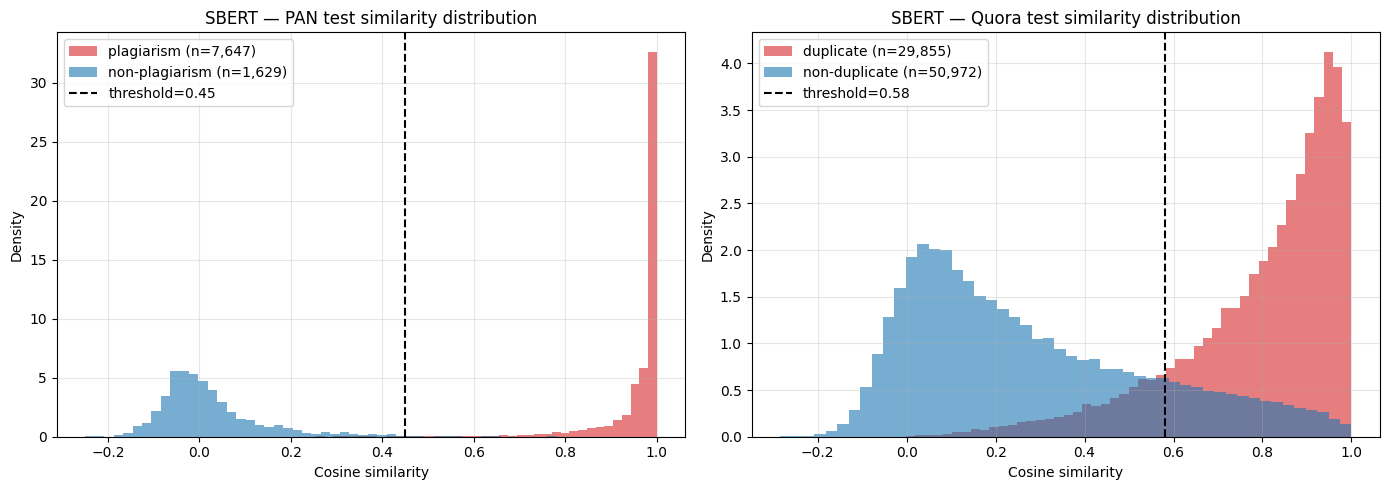

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PAN
ax = axes[0]
for label, color, name in [(1,'tab:red','plagiarism'), (0,'tab:blue','non-plagiarism')]:
    subset = pan_aug[pan_aug['label'] == label]
    ax.hist(subset['similarity'], bins=50, alpha=0.6, density=True,
            label=f'{name} (n={len(subset):,})', color=color)
ax.axvline(PAN_THRESHOLD, color='black', linestyle='--', label=f'threshold={PAN_THRESHOLD:.2f}')
ax.set_xlabel('Cosine similarity'); ax.set_ylabel('Density')
ax.set_title('SBERT — PAN test similarity distribution')
ax.legend(); ax.grid(alpha=0.3)

# Quora
ax = axes[1]
q_aug = q_test_pairs.copy()
q_aug['similarity'] = q_test_sims
q_aug['prediction'] = q_preds
for label, color, name in [(1,'tab:red','duplicate'), (0,'tab:blue','non-duplicate')]:
    subset = q_aug[q_aug['label'] == label]
    ax.hist(subset['similarity'], bins=50, alpha=0.6, density=True,
            label=f'{name} (n={len(subset):,})', color=color)
ax.axvline(Q_THRESHOLD, color='black', linestyle='--', label=f'threshold={Q_THRESHOLD:.2f}')
ax.set_xlabel('Cosine similarity'); ax.set_ylabel('Density')
ax.set_title('SBERT — Quora test similarity distribution')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model3_distributions.png', dpi=120)
plt.show()

## 14. Save results

In [19]:
import json

# Save metrics CSV locally
results_df.to_csv(RESULTS_DIR / 'model3_metrics.csv', index=False)

# Save metrics to Drive
drive_results = Path('/content/drive/MyDrive/pan-processed/model3_results')
drive_results.mkdir(exist_ok=True)
results_df.to_csv(drive_results / 'model3_metrics.csv', index=False)

# Save results JSON
with open(RESULTS_DIR / 'model3_results.json', 'w') as f:
    json.dump({'pan': pan_metrics, 'quora': q_metrics}, f, indent=4)

print('Saved:')
print(f'  results/model3_metrics.csv')
print(f'  results/model3_results.json')
print(f'  Drive: pan-processed/model3_results/model3_metrics.csv')
print(f'  Model already on Drive: pan-processed/model3_sbert_best/')
print(f'\nModel 3 complete.')
print(f'PAN   F1: {pan_metrics["f1"]:.4f}')
print(f'Quora F1: {q_metrics["f1"]:.4f}')

Saved:
  results/model3_metrics.csv
  results/model3_results.json
  Drive: pan-processed/model3_results/model3_metrics.csv
  Model already on Drive: pan-processed/model3_sbert_best/

Model 3 complete.
PAN   F1: 0.9955
Quora F1: 0.8068
